# Testing MG-cs2

In this notebook, I test a novel scenario in which the dark energy sound speed sources the braiding function $\alpha_B$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb

In [9]:
def get_camb_solution(alpha_K_0, cs2, omega_m, w0, wa, use_cs2):
    ombh2 = 0.0122
    h = 0.7
    omch2 = (omega_m - ombh2/h**2)*h**2
    cosmo = camb.set_params(
        H0=100*h, ombh2=ombh2, omch2=omch2, As=2.1e-9, ns=0.96, tau=0.06,
        num_nu_massless=3.044, WantTransfer=True, w=w0, wa=wa,
        dark_energy_model="fluid" if (1+w0)*(1+w0+wa) > 0 else "ppf",
        cs2_0=cs2, use_cs2=use_cs2, alpha_K_0=alpha_K_0, alpha_K_parametrization=0
    )
    cosmo.set_matter_power(redshifts=(0,), kmax=3)
    results = camb.get_background(cosmo)
    cl_tt = results.get_cmb_power_spectra(cosmo, CMB_unit="muK")["total"][:, 0]
    kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=200)
    log_a = results.Params.log_a
    alpha_B = results.Params.alpha_B
    mu = results.Params.mu
    return log_a*np.log10(np.e), alpha_B, mu, kh, z, pk, cl_tt

Text(0, 0.5, '$C_\\ell^{TT}$')

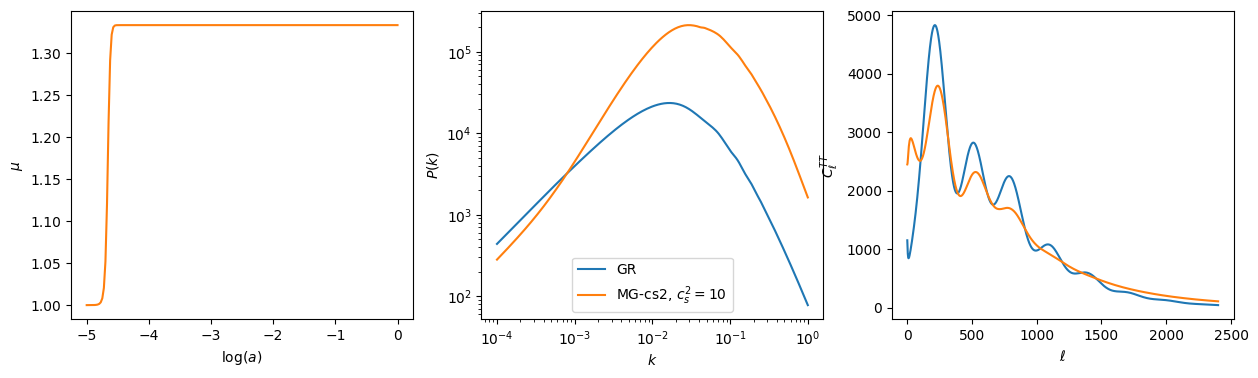

In [12]:
log_a, alpha_B, mu, kh, z, pk_mg, cl_tt_mg = get_camb_solution(alpha_K_0=1e-3, cs2=1, omega_m=0.3, w0=-0.7, wa=-0.6, use_cs2=True)
_, _, _, kh, z, pk_gr, cl_tt_gr            = get_camb_solution(alpha_K_0=1e-3, cs2=1, omega_m=0.3, w0=-0.7, wa=-0.6, use_cs2=False)
ell = np.arange(len(cl_tt_gr))

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(log_a, mu, color="tab:orange")
axs[0].set_xlabel("$\\log(a)$")
axs[0].set_ylabel("$\\mu$")

axs[1].loglog(kh, pk_gr[0], label="GR")
axs[1].loglog(kh, pk_mg[0], label="MG-cs2, $c_s^2 = 10$")
axs[1].set_xlabel("$k$")
axs[1].set_ylabel("$P(k)$")
axs[1].legend()

axs[2].plot(ell[2:], cl_tt_gr[2:])
axs[2].plot(ell[2:], cl_tt_mg[2:])
axs[2].set_xlabel("$\\ell$")
axs[2].set_ylabel("$C_\\ell^{TT}$")

In [8]:
np.array(mu)

array([       nan, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.00000001, 1.00000006, 1.0000004 , 1.00000322, 1.00003001,
       1.00032609, 1.0041066 , 1.05249001, 1.25593886, 1.32859423,
       1.33314058, 1.33332684, 1.33333315, 1.33333333, 1.33333333,
       1.33333333, 1.33333333, 1.33333333, 1.33333333, 1.33333333,
       1.33333333, 1.33333333, 1.33333333, 1.33333333,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        